# Notebook for calculating APWP from the VGP compilation and using the method of Gallo et al., 2023 to propagate uncertainty through the path

- using only igneous rock data
- no age model used at the site level

## import Python libraries

In [1]:
import ast 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmagpy import ipmag, pmag
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm

from matplotlib.colors import Normalize, colorConverter
from matplotlib.cm import ScalarMappable

import seaborn as sns
import scipy.stats as st

import cartopy
import cartopy.crs as ccrs

from vgptools.utils import *
from vgptools.utils_visualization import *
from vgptools.utils_classes import *
from vgptools.utils_APWPs import *

%matplotlib inline
%config InlineBackend.figure_formats = 'retina'

## import site-level compilation data

In [2]:
Keweenawan_track_site_data = pd.read_csv('../data/pmag_compiled/Keweenawan_track_sites_w_MAD_conversion.csv')
Keweenawan_track_site_data_no_seds = Keweenawan_track_site_data[Keweenawan_track_site_data['geologic_classes'] != 'Sedimentary']
Keweenawan_track_site_data_no_seds.head()

,pole_name,citations,location,site,lat,lon,age,age_high,age_low,age_unit,...,lithologies,geologic_types,age_model,height_type,height,height_upper,height_lower,paleolatitude,Plon,Plat
0,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(11.8 to 26.4),48.8122,272.3380,1108.0,1110.0,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,11.8,NaN,NaN,-54.692457,229.588330,33.098356
1,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(116.3 to 118.8),48.8062,272.3366,1108.0,1110.0,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,116.3,NaN,NaN,-54.393410,231.831739,30.447349
2,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(119.7 to 122.1),48.8060,272.3366,1108.0,1110.0,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,119.7,NaN,NaN,-52.341346,223.912252,35.321456
3,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(122.1 to 123.7),48.8058,272.3367,1108.0,1110.0,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,122.1,NaN,NaN,-52.630096,229.585495,29.952660
4,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(28.3 to 29.2),48.8107,272.3377,1108.0,1110.0,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,28.3,NaN,NaN,-49.396782,210.954452,45.769076


In [3]:
Keweenawan_track_site_data['geologic_classes'].unique()

array(['Extrusive:Igneous', 'Intrusive:Igneous', 'Sedimentary'],
      dtype=object)

## Bootstrap VGP based + MC age based APWP implementing Gallo et al., 2023 method

## The following function generates a bootstrap sample $X_b$ from the original dataset $X$. Then, it uses Monte Carlo resampling to generate for each site-level sample $X_{bi}$:

This uncertainty propagation algorithm has the following steps:

1. Generate a Monte Carlo sample-level compilation within each site in the compilation from the original dataset. 

2. In the bootstrap site-level compilation, for each site-level sample, generate a Monte Carlo sample (n=dir_n_sample) of directions (dec, inc) assuming Fisher distributed uncertainty using the directional kappa parameter (dir_k). 

3. For each Monte-Carlo sampled direction, assign an age associated with the direction using the assigned type of age distribution. If the pole is assigned a uniform age uncertainty, do uniform age sampling bracketed by the upper and lower age assignment. If the pole is assigned a normal age uncertainty, do normal age sampling with the mean and standard deviation of the age assignment, with the standard deviation calculated as the half of the difference between the nominal age and the age upper/age lower. 

4. Calculate the VGP associated with the resampled site directions. 


Note that in Gallo et al., 2023, if site-level data has no reported kappa, we take the mean of the population instead. In this Keweenawan Track compilation, study Books, 1972 did not report sample number for each site, and did not report site level precision parameter or alpha95 uncertainty angles. The approach we took is to use the site-mean precision parameter for each site, instead of taking the mean of the entire compiulation dataset as the alternative. 

## Run an ensemble of Moving Avergaes:

First, we set the parameters of the moving average

In [4]:
# Set the parameters for the Moving average
window_length= 20
time_step= 1 
max_age= 1115
min_age= 1075

n_sims = 50

## We now proceed to run the workflow a great number of times in order to to get the ensemble statistics.

### Let's run the workflow a great number of times without the sedimentary records

In [5]:
np.random.seed(2025)

df_RM_ensemble, pseudo_sites_ensemble = ensemble_RMs_parallel(
    Keweenawan_track_site_data_no_seds,
    n_sims=n_sims,
    n_jobs=os.cpu_count()-1    # or -1 for all cores
)

[Parallel(n_jobs=13)]: Using backend LokyBackend with 13 concurrent workers.


[Parallel(n_jobs=13)]: Done  36 out of  50 | elapsed:    4.9s remaining:    1.9s
[Parallel(n_jobs=13)]: Done  47 out of  50 | elapsed:    5.4s remaining:    0.3s
[Parallel(n_jobs=13)]: Done  50 out of  50 | elapsed:    5.4s finished


In [6]:
df_RM_ensemble

,age,N,n_studies,k,A95,csd,plon,plat,foliation,lineation,...,elong_dir,effective_age,effective_age_std,effective_age_median,distance2age,GCD,APW_rate,APW_rate_eff_age,angle,run
0,1075.0,53.0,4.0,32.633817,3.474541,14.179179,180.574435,20.149724,0.461921,3.266353,...,90.506285,1083.0,0.781401,1082.0,8.0,NaN,NaN,NaN,NaN,0.0
1,1076.0,77.0,5.0,27.547742,3.132360,15.432704,181.841493,18.145835,0.279015,3.169744,...,99.322694,1083.0,1.120050,1083.0,6.0,2.334112,2.334112,NaN,31.126643,0.0
2,1077.0,85.0,4.0,22.831878,3.284432,16.951737,181.854990,19.658281,0.530061,2.867424,...,98.026043,1084.0,1.211836,1084.0,7.0,1.512500,1.512500,1.512500,172.250146,0.0
3,1078.0,107.0,5.0,25.404042,2.763764,16.070656,181.726159,20.604355,0.368621,3.041540,...,113.133980,1084.0,1.430244,1084.0,7.0,0.953776,0.953776,NaN,60.549781,0.0
4,1079.0,121.0,5.0,32.647299,2.280427,14.176251,183.392232,19.959196,0.467288,3.261823,...,114.612700,1084.0,1.529750,1084.0,5.0,1.690692,1.690692,NaN,173.762453,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2045,1111.0,148.0,6.0,22.422735,2.503245,17.105695,211.747461,42.455416,0.418953,2.877902,...,130.527811,1107.0,1.873776,1107.0,-1.0,2.218963,2.218963,NaN,3.084097,49.0
2046,1112.0,146.0,6.0,24.815525,2.390555,16.260103,214.528230,43.800018,0.620082,2.917116,...,133.681644,1107.0,1.876228,1108.0,-5.0,2.434283,2.434283,NaN,168.838854,49.0
2047,1113.0,146.0,6.0,22.747219,2.501635,16.983252,216.834061,44.422572,0.436715,2.894149,...,126.344767,1108.0,2.025400,1108.0,-6.0,1.768665,1.768665,1.768665,76.444825,49.0
2048,1114.0,146.0,6.0,21.856256,2.554502,17.325953,215.851054,45.465661,0.236047,2.930829,...,133.525644,1108.0,1.905854,1108.0,-7.0,1.253822,1.253822,NaN,19.223190,49.0


In [7]:
pseudo_sites_ensemble

,study,site,height,age,dec,inc,slat,slon,spolarity,plon,plat,run
0,Osler reverse lower,SI1(11.8 to 26.4),11.8,1105.507787,72.473908,-69.531723,48.812200,272.338000,r,231.641384,28.974699,0.0
1,Osler reverse lower,SI1(116.3 to 118.8),116.3,1109.099055,70.561912,-69.678858,48.806200,272.336600,r,232.730209,28.309712,0.0
2,Osler reverse lower,SI1(119.7 to 122.1),119.7,1108.860021,79.665688,-68.258301,48.806000,272.336600,r,226.658027,30.971600,0.0
3,Osler reverse lower,SI1(122.1 to 123.7),122.1,1109.485688,79.308732,-68.515909,48.805800,272.336700,r,227.150437,31.043865,0.0
4,Osler reverse lower,SI1(28.3 to 29.2),28.3,1106.554011,112.524523,-66.395121,48.810700,272.337700,r,209.069505,47.108496,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
30995,Cardenas Basalt,CB17,NaN,1082.149722,262.780727,49.465628,36.111389,-111.855278,n,186.990862,12.113167,49.0
30996,Cardenas Basalt,CB18,NaN,1081.999937,290.888097,54.499109,36.111667,-111.855833,n,179.010867,35.040217,49.0
30997,Cardenas Basalt,CB8,NaN,1082.050906,272.028884,36.487502,36.107222,-111.848611,n,173.691996,13.369344,49.0
30998,Cardenas Basalt,CB9,NaN,1082.579912,285.805402,27.505321,36.107330,-111.849290,n,161.115079,21.187716,49.0


In [8]:
# df_RM_ensemble.to_csv('../code/code_output/Keweenaw_track_ensemble_RMs.csv', index=False)

In [9]:
# df_RM_ensemble = pd.read_csv('../code/code_output/Keweenaw_track_ensemble_RMs.csv')

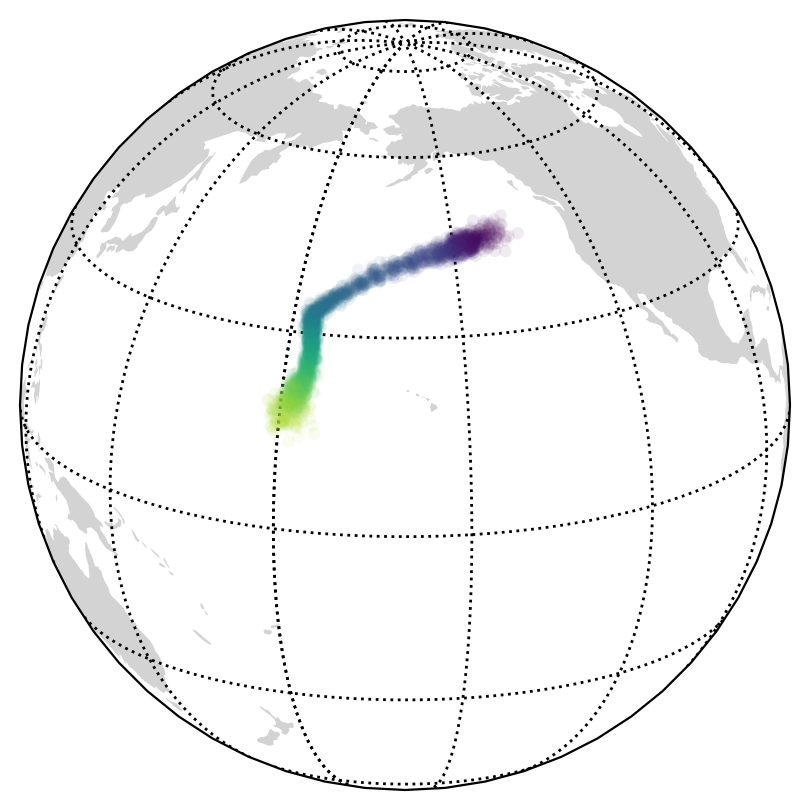

In [10]:
ax = ipmag.make_orthographic_map(200, 20, land_edge_color='none', land_color='lightgrey', figsize=(5,5))
ipmag.plot_poles_colorbar(ax, df_RM_ensemble['plon'], df_RM_ensemble['plat'], 
                          np.zeros(df_RM_ensemble.shape[0]), marker='o', 
                          colorvalues=df_RM_ensemble['age'], vmin=1070, vmax=1115, 
                          colormap='viridis_r',
                          alpha=0.08, edgecolor='none', colorbar=0)
# plt.savefig('../figure/Keweenawan_no_seds_ensemble_VGPs.png', dpi=300, bbox_inches='tight')

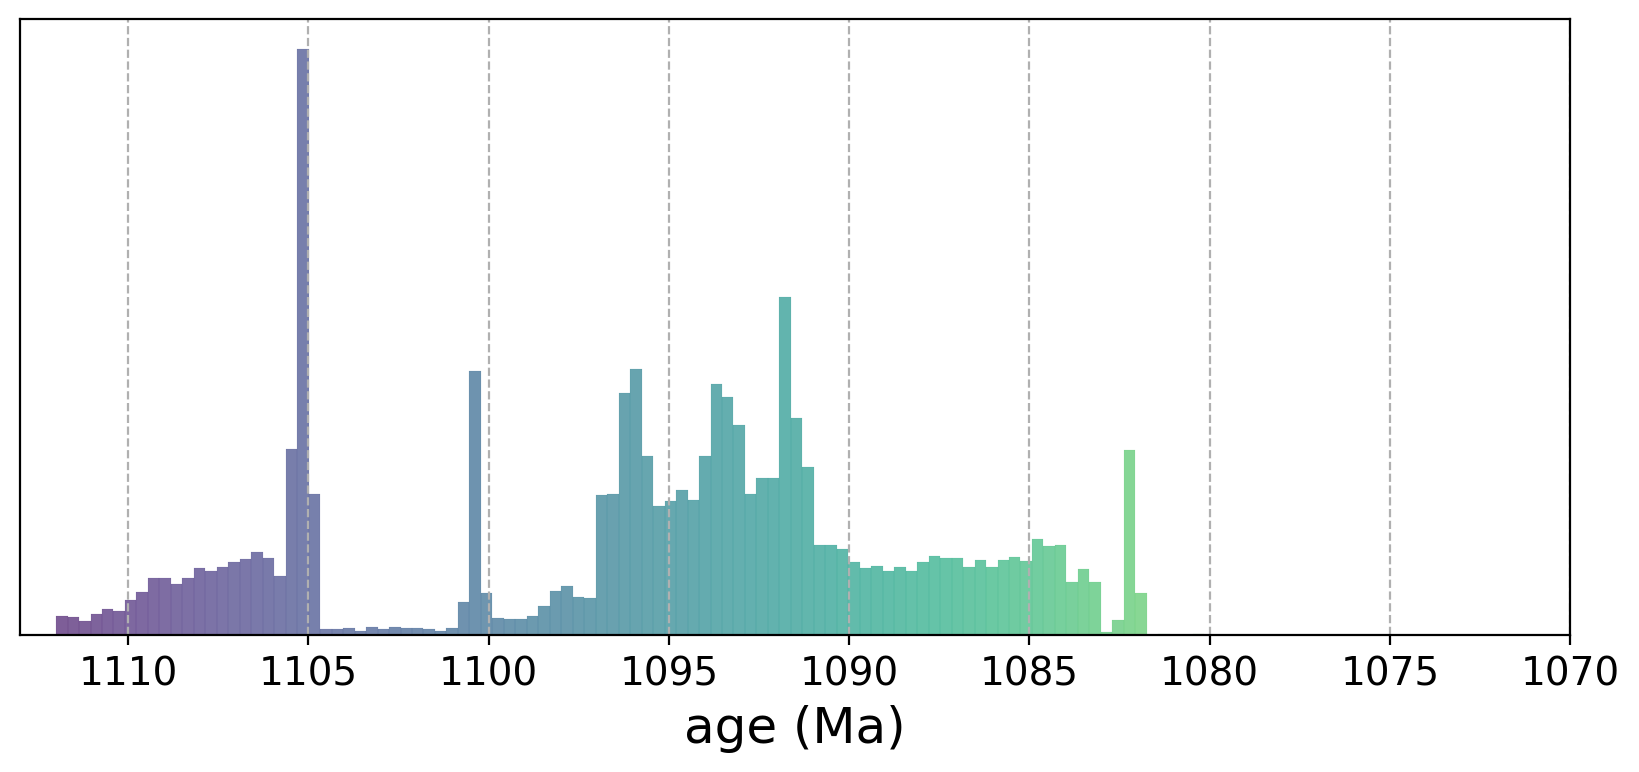

In [11]:
# Create a categorical variable based on binning the data

bins = 100
hist, bin_edges = np.histogram(pseudo_sites_ensemble['age'], bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1070, vmax=1115)
cmap = plt.cm.viridis_r

# Plot the histogram
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(bins):
    ax.bar(bin_edges[i], hist[i], width=bin_edges[1]-bin_edges[0],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.0), lw=0.05)
    
plt.gca().invert_xaxis()
plt.grid(1, ls='--')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)
plt.xlim(1113, 1070)
ax.set_yticks([])
plt.xticks(fontsize=14)
ax.set_xlabel('age (Ma)', fontsize=18)
# plt.savefig('../figure/Keweenawan_no_seds_ensemble_site_age_hist.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Visualization Using the effective age as the age of the window

### First we need to calculate the time-varying Ensemble statistics 
We take advantage of the groupby method to perform the statistics of each parameter of interest in the entire datade grouped by effective age

quantile() and PC() are classes aiding this calculations

## Calculate APW rate from the ensemble poles

In [12]:
ensemble_rates = pd.DataFrame()
for j in range(n_sims):
    df = pd.DataFrame()
    for i in np.sort(df_RM_ensemble['effective_age'].unique()):
        pole = df_RM_ensemble[df_RM_ensemble['effective_age'] == i].sample(n=1)
        df = pd.concat([df, pole], ignore_index=True)
    # The following block calculates rate of polar wander (degrees per million years) 
    df['run'] = j
    df['PPcartesian'] = df.apply(lambda row: spherical2cartesian([np.radians(row['plat']),np.radians(row['plon'])]), axis = 1)
    df['PP_prev'] = df['PPcartesian'].shift(periods = 1)
    df['PP_next'] =  df['PPcartesian'].shift(periods = -1)
    df['GCD'] = df.apply(lambda row: np.degrees(GCD_cartesian(row['PP_prev'], row['PPcartesian'])), axis = 1)
    df['APW_rate'] = df['GCD']/df['effective_age'].diff()
    ensemble_rates = pd.concat([ensemble_rates, df], ignore_index=True)

In [13]:
# Set the level confidence at which we want to work 
quantile = 95

# Since the Latitude and Longitude covaries, we need to calculate the Principal component for each timre-dependant point Cloud 
# the class PC() has also methods to aid in the calculatrio
ensemble_PC_eff_age = PC(df_RM_ensemble,"effective_age","plat","plon") # set principal component for each Age

# # Ensemble's parameters (e.g. Apparent polar wander rate, age difference)
ensemble_apw_eff = quantiles(df_RM_ensemble,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes
ensemble_apw_ef_ = quantiles(ensemble_rates,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes

ensemble_n_studies = quantiles(ensemble_rates,"effective_age","n_studies")
ensemble_n_vgps = quantiles(ensemble_rates,"effective_age","N")

In [14]:
df_RM_ensemble.columns

Index(['age', 'N', 'n_studies', 'k', 'A95', 'csd', 'plon', 'plat', 'foliation',
       'lineation', 'collinearity', 'coplanarity', 'elong_dir',
       'effective_age', 'effective_age_std', 'effective_age_median',
       'distance2age', 'GCD', 'APW_rate', 'APW_rate_eff_age', 'angle', 'run'],
      dtype='object')

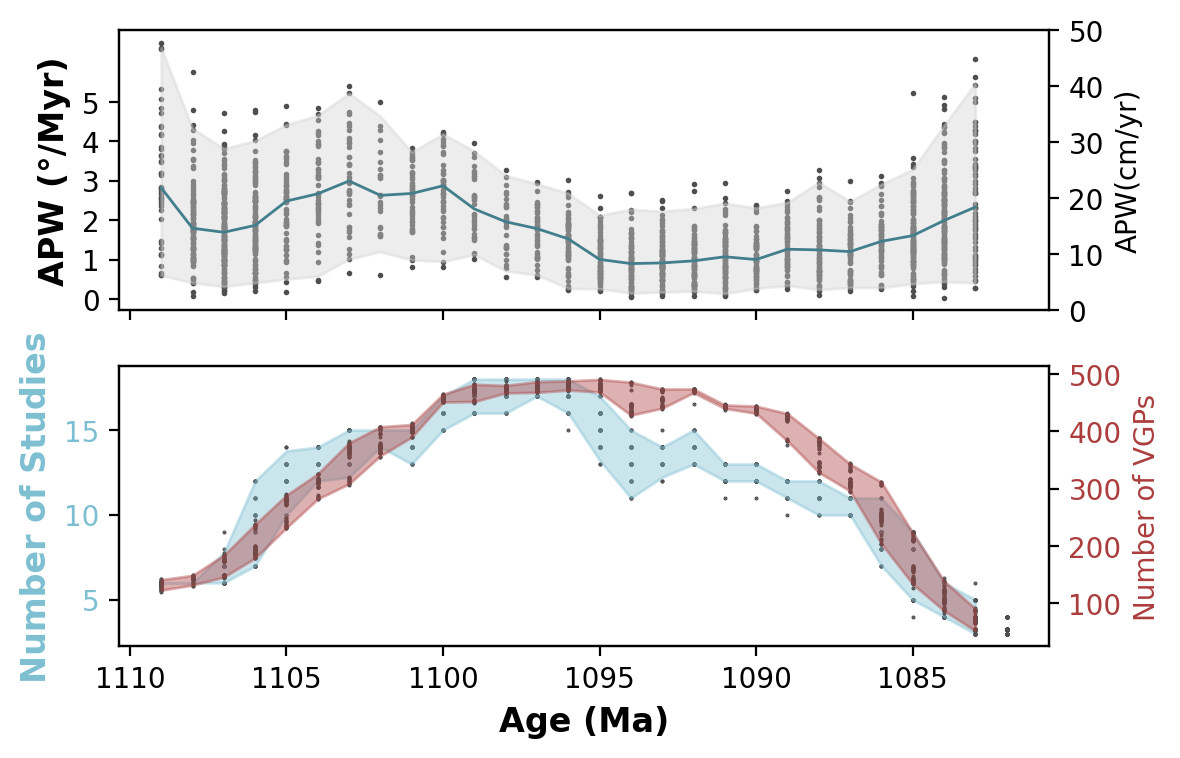

In [15]:
# sns.reset_orig
# sns.set_theme(style="darkgrid")
# sns.set_theme(style="white", palette=None)
fig, axes = plt.subplots(2, 1, figsize=(6,4), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'APW (°/Myr)', fontweight ='bold', fontsize = 12)
axes[1].set_ylabel(r'Number of Studies', fontweight ='bold', fontsize = 12, color="#7DBFD2")
axes[1].set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)

# red = ##7F4141
for run, df_run in df_RM_ensemble.groupby('run'):
    axes[0].scatter(df_run.effective_age.to_numpy(), df_run.APW_rate.to_numpy(), color="#4F4F4F", zorder =0, s=1)
axes[0].fill_between(np.sort(ensemble_apw_eff.X)[1:], ensemble_apw_eff.q025[1:],ensemble_apw_eff.q975[1:], color= "lightgrey", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[0].plot(np.sort(ensemble_apw_eff.X), ensemble_apw_eff.q50,color="#427E8C", zorder =3, linewidth=1, label="Ensemble Median")
# axes[0].set_ylim(0, 5.0)
axes[0].set_yticks([0, 1, 2, 3, 4, 5])
ax1 = axes[0].twinx()
ax1.set_yticks([0, 1, 2, 3, 4, 5], [0, 10, 20, 30, 40, 50])
ax1.set_ylabel('APW(cm/yr)', color="k")

for run, df_run in ensemble_rates.groupby('run'):
    axes[1].scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.n_studies.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
axes[1].fill_between(np.sort(ensemble_n_studies.X)[1:], ensemble_n_studies.q025[1:],ensemble_n_studies.q975[1:], color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[1].tick_params(axis='y', labelcolor="#7DBFD2")
ax2 = axes[1].twinx()  # instantiate a second axes that shares the same x-axis

for run, df_run in ensemble_rates.groupby('run'):
    ax2.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.N.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
ax2.fill_between(np.sort(ensemble_n_vgps.X)[1:], ensemble_n_vgps.q025[1:],ensemble_n_vgps.q975[1:], color= "#ac3d3d", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
ax2.set_ylabel('Number of VGPs', color="#ac3d3d")
ax2.tick_params(axis='y', labelcolor="#ac3d3d")
ax2.grid(False)
# axes[3]


plt.gca().invert_xaxis()
# axes[0].legend(loc="upper left")
# axes[2].legend(loc="upper left")
# plt.savefig('../figure/Keweenawan_ensemble_no_seds_stats.pdf', bbox_inches='tight')


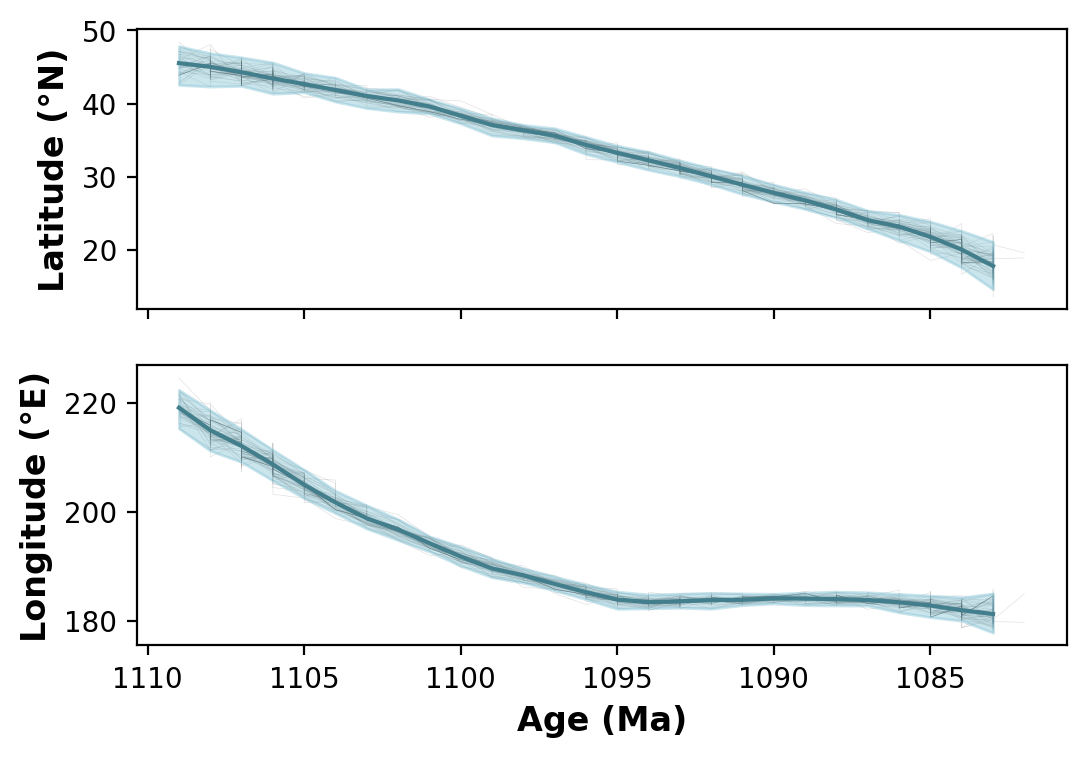

In [16]:
# sns.reset_orig
# sns.set_theme(style="darkgrid")
# sns.set_theme(style="white", palette=None)
fig, axes = plt.subplots(2, 1, figsize=(6,4), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'Latitude (°N)', fontweight ='bold', fontsize = 12)
axes[1].set_ylabel(r'Longitude (°E)', fontweight ='bold', fontsize = 12)
axes[1].set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)

# plot 50 runs to save computational cost and very dense graphics 
# df_RM_ensemble_50 = df_RM_ensemble[df_RM_ensemble['run'].isin(range(0,100))]

# LATITUDES 
for run, df_run in df_RM_ensemble.groupby('run'):
    axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)

axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[0].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[2], ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[3], color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
# axes[0].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#314B54", s = 15,  label = 'Principal component of the age ensemble')  
axes[0].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#427E8C")  

# LONGITUDES     
for run, df_run in df_RM_ensemble.groupby('run'):
    axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)
axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[1].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[0], ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[1], color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
# axes[1].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#314B54", s = 15,  label = 'Principal component of the age ensemble')
axes[1].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#427E8C")  


plt.gca().invert_xaxis()

# plt.savefig('../figure/Keweenawan_ensemble_no_seds_stats_APW_components.pdf', bbox_inches='tight')


### Visualizing the actual path

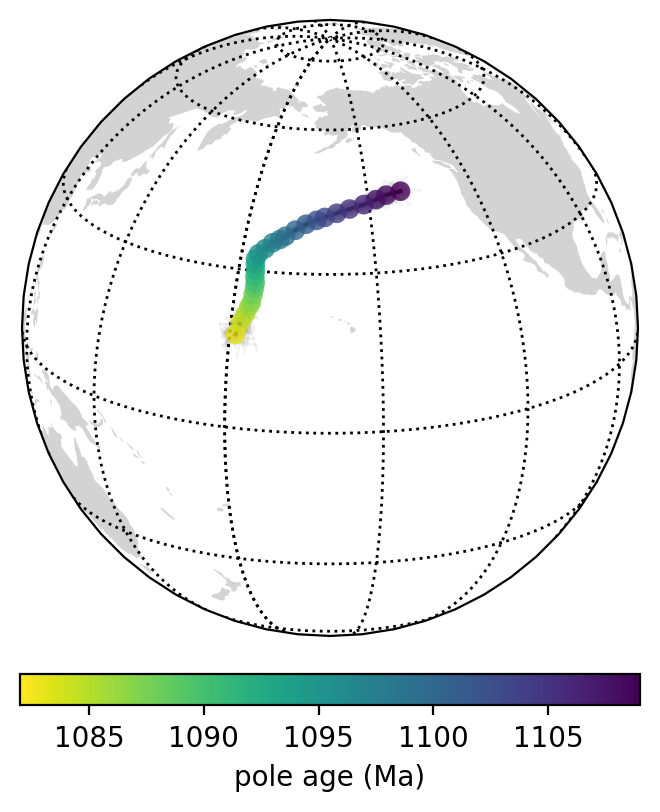

In [24]:
# Visualization

ax = ipmag.make_orthographic_map(200, 20, ocean_color=None, land_edge_color=None, land_color='lightgrey', figsize=(5,5))

# A black path for the time-varying Principal Component.
plt.plot(ensemble_PC_eff_age.PC(quantile)[0].tolist(), ensemble_PC_eff_age.PC(quantile)[1].tolist(),transform = ccrs.Geodetic(), color = "black", alpha = 1, linewidth=1.5, zorder=1)


paleopole_lats, paleopole_lons, eff_ages = ensemble_PC_eff_age.PC(quantile)[1].tolist(), ensemble_PC_eff_age.PC(quantile)[0].tolist(),ensemble_PC_eff_age.X.tolist()

# for i in zip(ensemble_PC_eff_age.PC(quantile)[1].tolist(), ensemble_PC_eff_age.PC(quantile)[0].tolist(),ensemble_PC_eff_age.X.tolist()):
#     plot_pole(i[0],i[1],i[2],ensemble_PC_eff_age.X.min(),ensemble_PC_eff_age.X.max(),ax)
    
# Runs in grey
for run, df_run in df_RM_ensemble[df_RM_ensemble['run']<500].groupby('run'):
    plt.plot(df_run.plon.tolist(), df_run.plat.tolist(),transform = ccrs.Geodetic(), color = "grey", alpha = 0.1, linewidth=0.9,  zorder=0) #linewidth=0.8,


ipmag.plot_poles_colorbar(ax, paleopole_lons[1:], paleopole_lats[1:], np.zeros(len(paleopole_lons[1:])), colorvalues = eff_ages[1:], vmin=np.min(eff_ages), vmax=np.max(eff_ages),
                           marker='o', colormap = 'viridis_r', markersize=50, edgecolor='none', alpha=0.8)

# plt.savefig('../figure/Keweenawan_no_seds_ensemble_paleopoles.pdf', bbox_inches='tight')
plt.show()

## plot example age model (expected to be random age-height paris)

In [19]:
# let's show the decoupled VGP age and stratigraphy
NSVG_SW_ensemble = pseudo_sites_ensemble[pseudo_sites_ensemble['study'] == 'North Shore Volcanic Group (upper SW sequence)'].reset_index(drop=True)    
NSVG_SW_ensemble

,study,site,height,age,dec,inc,slat,slon,spolarity,plon,plat,run
0,North Shore Volcanic Group (upper SW sequence),ns050,3622.424125,1095.986846,293.120104,45.565728,46.88286,268.08416,n,181.936992,34.799734,0.0
1,North Shore Volcanic Group (upper SW sequence),ns051,3809.431070,1095.230705,293.207191,42.883049,46.88497,268.08801,n,179.939741,33.484695,0.0
2,North Shore Volcanic Group (upper SW sequence),ns051,3809.431070,1093.755215,296.202768,40.129975,46.88497,268.08801,n,175.901800,34.167494,0.0
3,North Shore Volcanic Group (upper SW sequence),ns053,3430.871282,1095.693492,298.672140,42.736988,46.87654,268.06891,n,175.823938,37.145798,0.0
4,North Shore Volcanic Group (upper SW sequence),ns055,3051.536951,1094.318723,284.463456,37.410881,46.87575,268.04751,n,182.719174,24.845961,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4345,North Shore Volcanic Group (upper SW sequence),GB4,6818.492721,1093.892444,287.217413,46.261193,47.20000,268.50000,n,186.711050,31.200922,49.0
4346,North Shore Volcanic Group (upper SW sequence),GB6,6874.792721,1093.550634,314.520334,46.730832,47.20000,268.50000,n,166.344868,49.899731,49.0
4347,North Shore Volcanic Group (upper SW sequence),GB7,6969.592721,1094.120483,300.055564,36.683427,47.10000,268.50000,n,171.039549,35.111960,49.0
4348,North Shore Volcanic Group (upper SW sequence),GB8,6979.692721,1096.557597,297.571762,36.991485,47.10000,268.50000,n,173.172333,33.577615,49.0


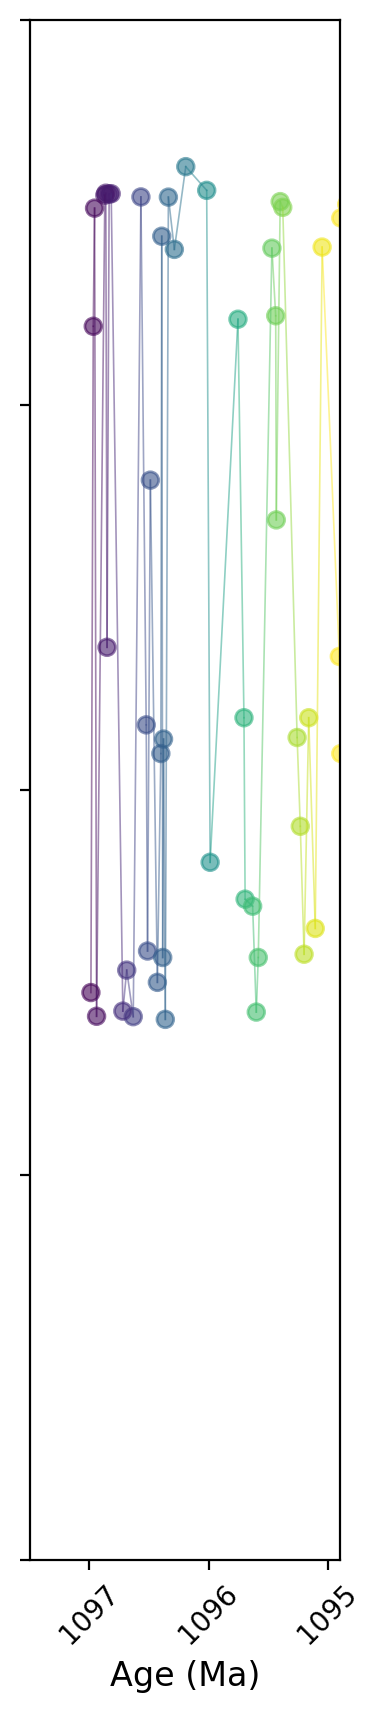

In [20]:
Normalize_NSVG_SW_ensemble = Normalize(vmin=1095, vmax=1097)
cmap_NSVG_SW_ensemble = plt.cm.viridis_r

plt.figure(figsize=(2, 10))
for run in NSVG_SW_ensemble['run'].unique()[:1]:
    this_df = NSVG_SW_ensemble[NSVG_SW_ensemble['run'] == run]
    this_df.sort_values('age', inplace=True)
    for i in range(this_df.shape[0]-1):
        plt.plot([this_df['age'].iloc[i], this_df['age'].iloc[i+1]], [this_df['height'].iloc[i], this_df['height'].iloc[i+1]], 
                 color = cmap_NSVG_SW_ensemble(Normalize_NSVG_SW_ensemble(this_df['age'].iloc[i]/2 + this_df['age'].iloc[i+1]/2)), ls='-', lw=0.6, alpha=0.5)
plt.scatter(NSVG_SW_ensemble['age'][:87], NSVG_SW_ensemble['height'][:87], 
            color = cmap_NSVG_SW_ensemble(Normalize_NSVG_SW_ensemble(NSVG_SW_ensemble['age'][:87])), alpha=0.6)
plt.xlim(1094.9, 1097.5)
# plt.ylim(0, 9000)
plt.xticks([1095, 1096, 1097], rotation=45, visible=True)
plt.yticks([0, 2000, 4000, 6000, 8000], [0, 2000, 4000, 6000, 8000], visible=0)
plt.gca().invert_xaxis()
plt.xlabel('Age (Ma)', fontsize=12)
# plt.ylabel('Height (m)', fontsize=12)
# plt.savefig('../figure/Keweenawan_NSVG_SW_no_age_model.pdf', bbox_inches='tight', transparent=True)
plt.show()

## APWP

In [21]:
# apwp_eff = {'Age': ensemble_PC_eff_age.X,
#            'Plat': ensemble_PC_eff_age.PC(quantile)[1],
#            'Plon': ensemble_PC_eff_age.PC(quantile)[0],
#            'Theta 95': ensemble_PC_eff_age.PC(quantile)[2],
#            'max lat': ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[3],
#            'min lat': ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[2],
#            'max lon': ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[1],
#            'min lon': ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[0],           
#           }
# df_apwp_eff = pd.DataFrame(apwp_eff)
# df_apwp_eff.head(20)
# df_apwp_eff.to_csv('../code/code_output/Keweenawan_track_VGP_APWP.csv', index = False)